# Reproduce Yang et al. (2026) angular power spectra

This notebook reproduces a subset of the statistics in
**Yang et al. (2026, MNRAS 548, 1–26; [arXiv:2512.09891](https://arxiv.org/abs/2512.09891))**
from the FLAMINGO **L2p8_m9** (`L2800N5040/HYDRO_FIDUCIAL`) integrated maps at
their **native $N_\mathrm{side}=4096** — no downgrading.

| Target (paper) | Quantity | Section here |
|----------------|----------|--------------|
| Fig. 8 (left) | CIB auto-power $D_\ell$ at 217/353/545/857 GHz | §3 |
| Table 3 | CIB frequency decorrelation $r_{\nu\nu'}$ | §4 |
| Fig. 10 | CIB–$y$ and CIB–$\kappa$ cross-spectra | §5 |
| Figs. 6–7 (diagnostics) | $y$, kSZ, $\kappa$ auto-spectra | §6 |

Data: `/rds/rds-lxu/flamingo/integrated_maps_synthetic/L2800N5040/HYDRO_FIDUCIAL/lightcone0_shells` (single
observer; the paper averages 8 lightcones). All maps are lensed and share the
same shell rotations, so cross-correlations are physical. Map I/O and spectrum
estimators come from the packaged `flamingo_mock` source (`src/`).

**Runtime note:** loading 7 full-sky maps (~6 GB) and computing ~20
`anafast` spectra at $N_\mathrm{side}=4096$, $\ell_\mathrm{max}=10^4$ is the
slow step (order tens of minutes). Spectra are cached to
`Spectra .npz` so re-runs only redo the figures.

In [1]:
from pathlib import Path

import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from flamingo_mock.config import CIB_FILES, KAPPA_FILE, KSZ_FILE, TSZ_FILE, MockConfig
from flamingo_mock.io import load_flamingo_map
from flamingo_mock import powerspectra as pspec

# Native resolution — no downgrade.
cfg = MockConfig()
NSIDE = cfg.nside           # 4096
assert NSIDE == 4096

LMAX = 10000                # paper figures reach ~1e4; use 3*NSIDE-1 for the full range
DELTA_ELL = 7               # Yang et al. bandpower width
SG_WINDOW = 15              # Savitzky-Golay display smoothing (odd)
SG_ORDER = 3
ANAFAST_ITER = 0            # 0 is faster; raise for slightly better accuracy

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
SPEC_CACHE = cfg.out_dir / "spectra_yang26" / f"spectra_nside{NSIDE}_lmax{LMAX}.npz"
SPEC_CACHE.parent.mkdir(parents=True, exist_ok=True)

print(f"data: {cfg.data_dir}")
print(f"Nside={NSIDE}, lmax={LMAX}, Delta_ell={DELTA_ELL}")
print(f"figure dir: {FIG_DIR.resolve()}")
print(f"spectrum cache: {SPEC_CACHE}")

data: /rds/rds-lxu/flamingo/integrated_maps_synthetic/L2800N5040/HYDRO_FIDUCIAL/lightcone0_shells
Nside=4096, lmax=10000, Delta_ell=7
figure dir: /scratch/scratch-lxu/flamingo_mock_analysis/figures
spectrum cache: /rds/rds-lxu/flamingo/integrated_maps_synthetic/spectra_yang26/spectra_nside4096_lmax10000.npz


In [2]:
# Publication-style Matplotlib + LaTeX
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

# Colourblind-friendly palette
CIB_COLORS = {217: "#0072B2", 353: "#E69F00", 545: "#009E73", 857: "#D55E00"}


def savefig(fig, name: str) -> None:
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png")
    print(f"Wrote {FIG_DIR / name}.pdf")

## 1. Load maps

Native $N_\mathrm{side}=4096$ RING maps (~800 MB each on disk, float64 in
memory). CIB maps are specific intensities in $\mathrm{Jy\,sr^{-1}}$; the tSZ
map is Compton $y$, the kSZ map is Doppler $b$ ($\Delta T/T_\mathrm{CMB}=-b$),
and $\kappa$ is the CMB lensing convergence.

In [3]:
FILES = {
    "kappa": KAPPA_FILE,
    "tsz": TSZ_FILE,        # Compton y
    "ksz": KSZ_FILE,        # Doppler b
    **{f"cib{nu}": fname for nu, fname in CIB_FILES.items()},
}

maps = {}
for key, fname in FILES.items():
    print(f"Loading {fname} ...")
    maps[key] = load_flamingo_map(cfg.data_dir / fname)  # native Nside=4096
    m = maps[key]
    print(f"  {key:8s}: mean={m.mean():.4e}, std={m.std():.4e}, npix={m.size:,}")

Loading kappa_rot.fits ...


  kappa   : mean=5.3154e-05, std=7.7610e-02, npix=201,326,592
Loading lensed_tSZ_rot.fits ...


  tsz     : mean=1.6109e-06, std=2.0692e-06, npix=201,326,592
Loading lensed_kSZ_rot.fits ...


  ksz     : mean=-1.3004e-07, std=1.5236e-06, npix=201,326,592
Loading lensed_CIB_rot_BANDPASS_F217_three_params.fits ...


  cib217  : mean=4.2928e+04, std=1.3295e+04, npix=201,326,592
Loading lensed_CIB_rot_BANDPASS_F353_three_params.fits ...


  cib353  : mean=1.7042e+05, std=5.0702e+04, npix=201,326,592
Loading lensed_CIB_rot_BANDPASS_F545_three_params.fits ...


  cib545  : mean=4.6901e+05, std=1.3646e+05, npix=201,326,592
Loading lensed_CIB_rot_BANDPASS_F857_three_params.fits ...


  cib857  : mean=9.4807e+05, std=3.0233e+05, npix=201,326,592


## 2. Compute spectra

Full-sky auto/cross-spectra with `anafast`, mean-subtracted and
pixel-window-deconvolved (`flamingo_mock.powerspectra.compute_cl`):

$$
C_\ell^{ab}=\frac{1}{2\ell+1}\sum_m a_{\ell m}\,b_{\ell m}^*,
\qquad
C_\ell \to C_\ell / W_\ell^{\mathrm{pix}\,2}.
$$

Results are cached to `.npz`; delete the cache file to force recomputation.

In [4]:
CIB_FREQS = sorted(CIB_FILES)  # [217, 353, 545, 857]
cib_key = {nu: f"cib{nu}" for nu in CIB_FREQS}

SPECTRA = []
for nu in CIB_FREQS:
    SPECTRA.append((f"cib_auto_{nu}", cib_key[nu], None))
for i, nu1 in enumerate(CIB_FREQS):
    for nu2 in CIB_FREQS[i + 1:]:
        SPECTRA.append((f"cib_x_{nu1}_{nu2}", cib_key[nu1], cib_key[nu2]))
for nu in CIB_FREQS:
    SPECTRA.append((f"cib_x_tsz_{nu}", cib_key[nu], "tsz"))
    SPECTRA.append((f"cib_x_kappa_{nu}", cib_key[nu], "kappa"))
SPECTRA += [
    ("tsz_auto", "tsz", None),
    ("ksz_auto", "ksz", None),
    ("kappa_auto", "kappa", None),
    ("tsz_x_kappa", "tsz", "kappa"),
]

if SPEC_CACHE.is_file():
    print(f"Loading cached spectra from {SPEC_CACHE}")
    cls = dict(np.load(SPEC_CACHE))
else:
    cls = {}
    for name, ka, kb in SPECTRA:
        print(f"  {name} ...", flush=True)
        cls[name] = pspec.compute_cl(
            maps[ka], maps[kb] if kb else None,
            lmax=LMAX, iter=ANAFAST_ITER,
        )
    np.savez(SPEC_CACHE, **cls)
    print(f"Cached -> {SPEC_CACHE}")

ell = np.arange(LMAX + 1)
print(f"Computed {len(cls)} spectra, lmax={LMAX}")

  cib_auto_217 ...


  cib_auto_353 ...


  cib_auto_545 ...


  cib_auto_857 ...


  cib_x_217_353 ...


...

  tsz_auto ...


  ksz_auto ...


  kappa_auto ...


  tsz_x_kappa ...


Cached -> /rds/rds-lxu/flamingo/integrated_maps_synthetic/spectra_yang26/spectra_nside4096_lmax10000.npz
Computed 22 spectra, lmax=10000


## 3. CIB auto-power spectra (cf. Fig. 8, left)

Yang et al. fit the three-parameter SED to Lenz et al. (2019) at 353/545/857
GHz. We plot $D_\ell$ for those bands plus 217 GHz as a consistency check.
The curves are Savitzky–Golay smoothed for display, as in the paper.

Wrote ../figures/yang26_fig8left_cib_auto_spectra.pdf


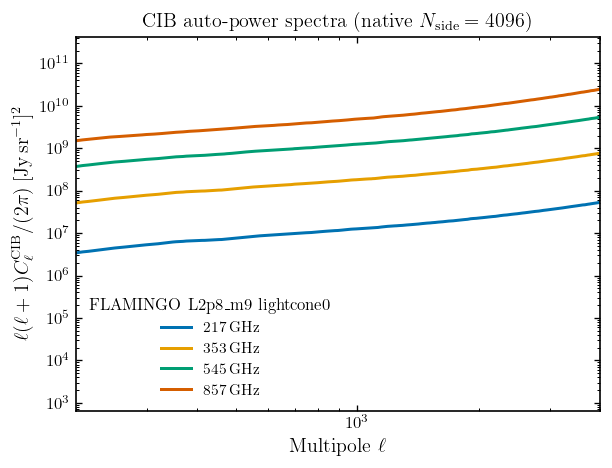

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 4.0))

for nu in CIB_FREQS:
    ell_b, cl_b = pspec.bin_cl(cls[f"cib_auto_{nu}"], DELTA_ELL)
    dl_b = pspec.dl_from_cl(ell_b, cl_b)
    dl_s = pspec.smooth_for_display(dl_b, SG_WINDOW, SG_ORDER)
    ax.loglog(ell_b, dl_s, color=CIB_COLORS[nu], lw=1.8,
              label=rf"${nu}\,\mathrm{{GHz}}$")

ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$\ell(\ell+1)C_\ell^{\mathrm{CIB}}/(2\pi)\;[\mathrm{Jy}\,\mathrm{sr}^{-1}]^{2}$")
ax.set_xlim(200, min(LMAX, 4000))
ax.legend(title=r"FLAMINGO L2p8\_m9 lightcone0", loc="lower left")
ax.set_title(r"CIB auto-power spectra (native $N_{\mathrm{side}}=4096$)")
fig.tight_layout()
savefig(fig, "yang26_fig8left_cib_auto_spectra")
plt.show()

## 4. CIB frequency decorrelation (cf. Table 3)

Decorrelation coefficient averaged over $150<\ell<1000$:

$$
r_{\nu\nu'}=\left\langle
\frac{C_\ell^{\nu\nu'}}{\sqrt{C_\ell^{\nu\nu}C_\ell^{\nu'\nu'}}}
\right\rangle_{150<\ell<1000}.
$$

Yang et al. report e.g. $r_{353\times545}\approx0.98$; a single lightcone
should reproduce this to within the lightcone-to-lightcone scatter.

   nu1 x nu2    r_mean     r_std
----------------------------------
 217 x 353      0.993     0.000
 217 x 545      0.956     0.003
 217 x 857      0.841     0.012
 353 x 545      0.983     0.001
 353 x 857      0.895     0.009
 545 x 857      0.959     0.004


Wrote ../figures/yang26_table3_cib_decorrelation.pdf


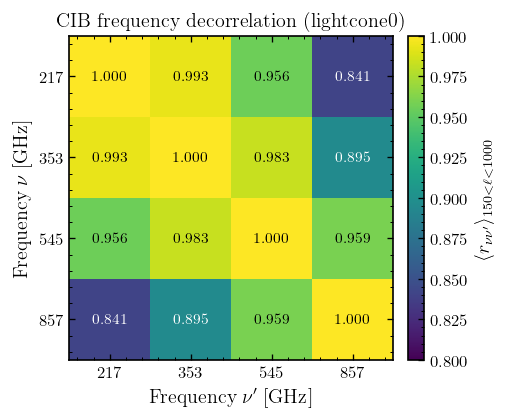

In [6]:
rows = []
print(f"{'nu1 x nu2':>12s}  {'r_mean':>8s}  {'r_std':>8s}")
print("-" * 34)
for i, nu1 in enumerate(CIB_FREQS):
    for nu2 in CIB_FREQS[i + 1:]:
        r_m, r_s = pspec.decorrelation(
            cls[f"cib_x_{nu1}_{nu2}"],
            cls[f"cib_auto_{nu1}"],
            cls[f"cib_auto_{nu2}"],
        )
        rows.append((nu1, nu2, r_m, r_s))
        print(f"{nu1:4d} x {nu2:<4d}  {r_m:8.3f}  {r_s:8.3f}")

n = len(CIB_FREQS)
R = np.eye(n)
for nu1, nu2, r_m, _ in rows:
    i, j = CIB_FREQS.index(nu1), CIB_FREQS.index(nu2)
    R[i, j] = R[j, i] = r_m

fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(R, vmin=0.8, vmax=1.0, cmap="viridis", origin="upper")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([rf"${nu}$" for nu in CIB_FREQS])
ax.set_yticklabels([rf"${nu}$" for nu in CIB_FREQS])
ax.set_xlabel(r"Frequency $\nu'\;[\mathrm{GHz}]$")
ax.set_ylabel(r"Frequency $\nu\;[\mathrm{GHz}]$")
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{R[i, j]:.3f}", ha="center", va="center",
                color="white" if R[i, j] < 0.92 else "black", fontsize=9)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$\langle r_{\nu\nu'}\rangle_{150<\ell<1000}$")
ax.set_title(r"CIB frequency decorrelation (lightcone0)")
fig.tight_layout()
savefig(fig, "yang26_table3_cib_decorrelation")
plt.show()

## 5. CIB–tSZ and CIB–$\kappa$ cross-spectra (cf. Fig. 10)

Left: $C_\ell^{\mathrm{CIB}\times y}$ in $10^{-6}\,\mathrm{Jy\,sr^{-1}}$.
Right: $\ell\,C_\ell^{\mathrm{CIB}\times\kappa}$ in $\mathrm{Jy\,sr^{-1}}$.
The paper's shaded bands are the scatter across eight lightcones; with a
single realization, expect agreement within that scatter at
$\ell\gtrsim300$.

Wrote ../figures/yang26_fig10_cib_tsz_kappa_cross.pdf


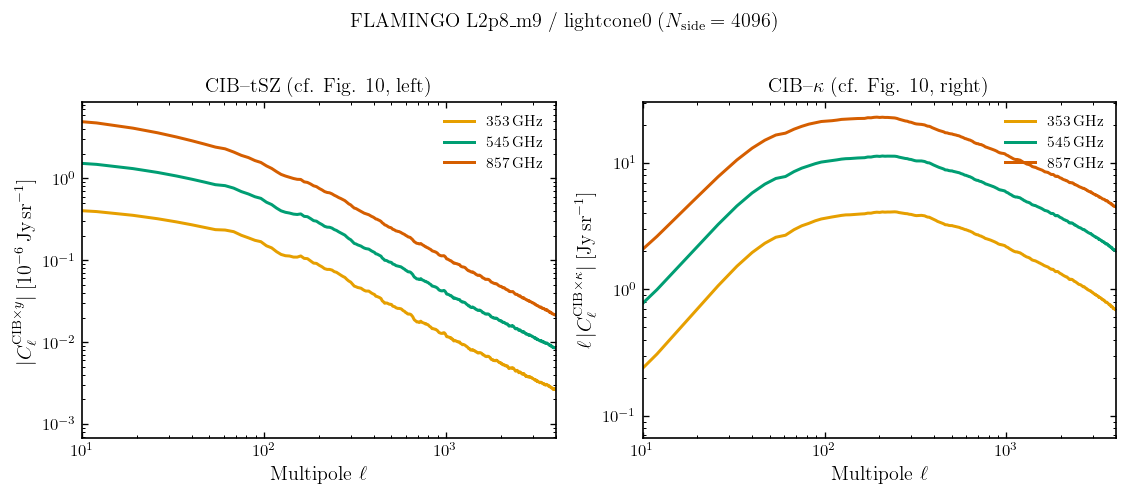

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0), sharex=True)

for nu in [353, 545, 857]:  # main bands shown in Fig. 10
    ell_b, cl_by = pspec.bin_cl(cls[f"cib_x_tsz_{nu}"], DELTA_ELL)
    ell_k, cl_bk = pspec.bin_cl(cls[f"cib_x_kappa_{nu}"], DELTA_ELL)
    y_tsz = pspec.smooth_for_display(np.abs(cl_by) * 1.0e6, SG_WINDOW, SG_ORDER)
    y_kap = pspec.smooth_for_display(np.abs(cl_bk), SG_WINDOW, SG_ORDER)
    axes[0].loglog(ell_b, y_tsz, color=CIB_COLORS[nu], lw=1.8,
                   label=rf"${nu}\,\mathrm{{GHz}}$")
    axes[1].loglog(ell_k, ell_k * y_kap, color=CIB_COLORS[nu], lw=1.8,
                   label=rf"${nu}\,\mathrm{{GHz}}$")

axes[0].set_xlabel(r"Multipole $\ell$")
axes[1].set_xlabel(r"Multipole $\ell$")
axes[0].set_ylabel(r"$|C_\ell^{\mathrm{CIB}\times y}|\;[10^{-6}\,\mathrm{Jy}\,\mathrm{sr}^{-1}]$")
axes[1].set_ylabel(r"$\ell\,|C_\ell^{\mathrm{CIB}\times\kappa}|\;[\mathrm{Jy}\,\mathrm{sr}^{-1}]$")
axes[0].set_xlim(10, min(LMAX, 4000))
axes[0].set_title(r"CIB--tSZ (cf. Fig. 10, left)")
axes[1].set_title(r"CIB--$\kappa$ (cf. Fig. 10, right)")
axes[0].legend(loc="upper right")
axes[1].legend(loc="upper right")

fig.suptitle(r"FLAMINGO L2p8\_m9 / lightcone0 ($N_{\mathrm{side}}=4096$)", y=1.02)
fig.tight_layout()
savefig(fig, "yang26_fig10_cib_tsz_kappa_cross")
plt.show()

## 6. Component auto-spectra: $y$, kSZ, $\kappa$ (cf. Figs. 6–7)

Diagnostics for the non-CIB components:

* $C_\ell^{yy}$ — Compton $y$ auto-spectrum;
* $C_\ell^{bb}$ — Doppler $b$ auto-spectrum, shown as thermodynamic
  $D_\ell^{TT}=T_\mathrm{CMB}^2\,D_\ell^{bb}$ in $\mu\mathrm{K}^2$
  (the kSZ contribution to any frequency channel);
* $C_\ell^{\kappa\kappa}$ — CMB lensing convergence auto-spectrum.

Wrote ../figures/yang26_figs67_tsz_ksz_kappa_autos.pdf


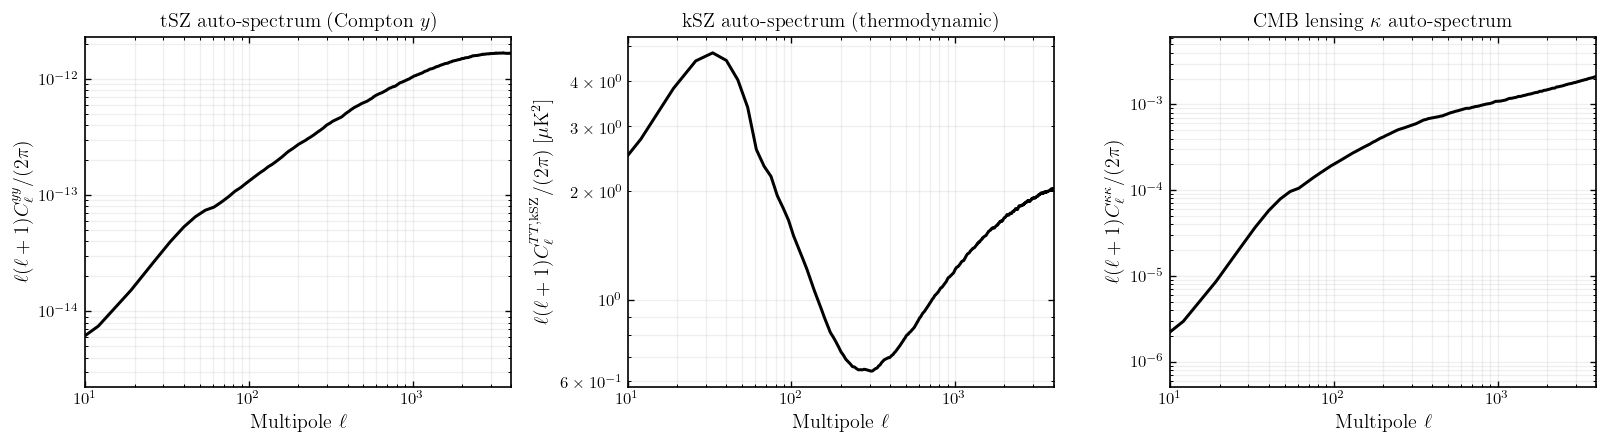

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

# tSZ y auto
ell_b, cl_b = pspec.bin_cl(cls["tsz_auto"], DELTA_ELL)
axes[0].loglog(ell_b, pspec.smooth_for_display(pspec.dl_from_cl(ell_b, cl_b), SG_WINDOW, SG_ORDER),
               color="k", lw=1.8)
axes[0].set_xlabel(r"Multipole $\ell$")
axes[0].set_ylabel(r"$\ell(\ell+1)C_\ell^{yy}/(2\pi)$")
axes[0].set_title(r"tSZ auto-spectrum (Compton $y$)")
axes[0].set_xlim(10, min(LMAX, 4000))

# kSZ auto in thermodynamic uK^2
ell_b, cl_b = pspec.bin_cl(cls["ksz_auto"], DELTA_ELL)
dl_ksz = pspec.dl_from_cl(ell_b, cl_b) * (cfg.t_cmb * 1.0e6) ** 2
axes[1].loglog(ell_b, pspec.smooth_for_display(dl_ksz, SG_WINDOW, SG_ORDER),
               color="k", lw=1.8)
axes[1].set_xlabel(r"Multipole $\ell$")
axes[1].set_ylabel(r"$\ell(\ell+1)C_\ell^{TT,\mathrm{kSZ}}/(2\pi)\;[\mu\mathrm{K}^2]$")
axes[1].set_title(r"kSZ auto-spectrum (thermodynamic)")
axes[1].set_xlim(10, min(LMAX, 4000))

# kappa auto
ell_b, cl_b = pspec.bin_cl(cls["kappa_auto"], DELTA_ELL)
axes[2].loglog(ell_b, pspec.smooth_for_display(pspec.dl_from_cl(ell_b, cl_b), SG_WINDOW, SG_ORDER),
               color="k", lw=1.8)
axes[2].set_xlabel(r"Multipole $\ell$")
axes[2].set_ylabel(r"$\ell(\ell+1)C_\ell^{\kappa\kappa}/(2\pi)$")
axes[2].set_title(r"CMB lensing $\kappa$ auto-spectrum")
axes[2].set_xlim(10, min(LMAX, 4000))

for ax in axes:
    ax.grid(True, which="both", alpha=0.2)

fig.tight_layout()
savefig(fig, "yang26_figs67_tsz_ksz_kappa_autos")
plt.show()

## 7. Notes on reproduction fidelity

1. **Single lightcone**: published curves average eight L2p8_m9 observers; we
   analyse only `lightcone0`, so large-scale ($\ell\lesssim300$) points —
   especially CIB–$y$ — can scatter around the paper's mean curves.
2. **Resolution**: all spectra here are at the native $N_\mathrm{side}=4096$
   with pixel-window deconvolution, matching the paper's analysis.
3. **Bandpowers**: $\Delta_\ell=7$ bins and Savitzky–Golay display smoothing
   follow the paper's plotting conventions; smoothing is cosmetic only.
4. **Absolute normalisation**: the CIB maps are bandpass-convolved specific
   intensities, so $D_\ell$ compares directly to Fig. 8 without unit
   conversions.